# 03 — Geometry Essentials

**Topic 3 of the math journey.** Geometry is the math of **shape, size, position, and
distance**. It looks visual, but it rests on careful definitions and proofs — and the
idea of **distance** comes back later as the foundation of vectors, norms, and "how far
apart are two data points" in machine learning.

## Quick recall (answers)
- $0.\overline{27} = \dfrac{27}{99} = \dfrac{3}{11}$ (block `27`, length 2 → denominator
  $10^2-1=99$, then simplify).
- $x^3\cdot x^5 = x^{8}$ (add exponents) and $(y^2)^4 = y^{8}$ (multiply exponents).

## What we cover today
1. Points, lines, rays, and angles (the basic objects).
2. Angle relationships, and a proof that **vertical angles are equal**.
3. Parallel lines cut by a transversal.
4. Triangles and a proof that the angles add to **180°**.
5. The **Pythagorean theorem** (with a proof).
6. Perimeter, area, and circles.
7. **Coordinate geometry**: distance, midpoint, slope — the bridge from geometry to
   algebra (and to AI).


## 1. The basic objects

- A **point** has a position but no size (drawn as a dot).
- A **line** is straight, has no thickness, and goes on forever in both directions.
- A **ray** starts at one point and goes forever in one direction.
- A **line segment** is the straight piece between two points $A$ and $B$, written
  $\overline{AB}$; its **length** is the distance from $A$ to $B$.
- An **angle** is formed by two rays sharing a start point (the **vertex**). We measure it
  in **degrees** ($^\circ$); a full turn is $360^\circ$.

Angle names by size:

| Name | Size |
|---|---|
| acute | between $0^\circ$ and $90^\circ$ |
| right | exactly $90^\circ$ (a square corner) |
| obtuse | between $90^\circ$ and $180^\circ$ |
| straight | exactly $180^\circ$ (a flat line) |

```
   right angle        acute            obtuse
      |                /                 \
      |               /                   \
      |_____         /_____            _____\
```


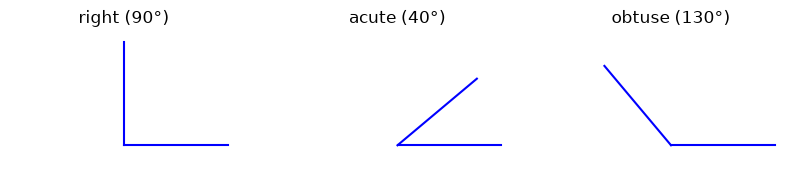

In [1]:
import numpy as np                      # numpy = arrays + math functions like cos/sin
import matplotlib.pyplot as plt

# Draw three angles by drawing two rays from a shared vertex at the origin (0,0).
def draw_angle(ax, degrees, title):
    a = np.radians(degrees)               # np.radians converts degrees -> radians (math funcs need radians)
    ax.plot([0, 1], [0, 0], 'b')          # first ray: along the positive x-axis
    ax.plot([0, np.cos(a)], [0, np.sin(a)], 'b')  # second ray: turned by 'degrees'
    ax.set_title(f"{title} ({degrees}°)")
    ax.set_xlim(-1.1, 1.1); ax.set_ylim(-0.2, 1.1); ax.set_aspect('equal'); ax.axis('off')

fig, axes = plt.subplots(1, 3, figsize=(10, 3))
draw_angle(axes[0], 90, "right")
draw_angle(axes[1], 40, "acute")
draw_angle(axes[2], 130, "obtuse")
plt.show()


## 2. Angle relationships

- Two angles are **complementary** if they add to $90^\circ$.
- Two angles are **supplementary** if they add to $180^\circ$.
- When two straight lines cross, the **opposite** angles are called **vertical angles**.

**Theorem.** Vertical angles are equal.

**Proof.** Two crossing lines make four angles. Call two neighbours $\alpha$ and $\beta$.
Together they form a straight line, so they are supplementary:
$$\alpha + \beta = 180^\circ.$$
On the other side of $\beta$ is the vertical angle $\gamma$ (opposite $\alpha$), and it is
*also* supplementary to $\beta$:
$$\gamma + \beta = 180^\circ.$$
Both equal $180^\circ - \beta$, therefore $\alpha = \gamma$. The opposite angles are
equal. ∎


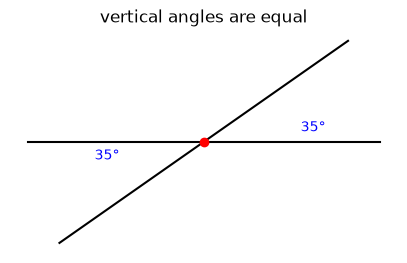

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# Two lines crossing at the origin. Vertical (opposite) angles are equal.
ang = 35                                   # angle of the slanted line, in degrees
t = np.radians(ang)
plt.figure(figsize=(5, 5))
plt.plot([-1, 1], [0, 0], 'k')                              # horizontal line
plt.plot([-np.cos(t), np.cos(t)], [-np.sin(t), np.sin(t)], 'k')  # slanted line
plt.plot(0, 0, 'ro')                       # the crossing point
plt.text(0.55, 0.06, f"{ang}°", color='blue')         # one angle
plt.text(-0.62, -0.10, f"{ang}°", color='blue')       # its EQUAL vertical angle
plt.gca().set_aspect('equal'); plt.axis('off'); plt.title("vertical angles are equal")
plt.show()


## 3. Parallel lines and a transversal

Two lines are **parallel** ($\parallel$) if they never meet, no matter how far we extend
them. A **transversal** is a line that crosses both.

When a transversal crosses two **parallel** lines, special equal angles appear:
- **corresponding angles** are equal (same position at each crossing),
- **alternate interior angles** are equal (the "Z" shape),
- **co-interior angles** are supplementary (add to $180^\circ$).

These facts are the key tool for the next proof.


## 4. Triangles, and why the angles sum to 180°

A **triangle** has three sides and three angles. Some types:
- by sides: **equilateral** (all equal), **isosceles** (two equal), **scalene** (all different);
- by angles: **acute**, **right** (one $90^\circ$), **obtuse**.

**Theorem.** The three interior angles of any triangle add to $180^\circ$.

**Proof.** Take triangle $ABC$ with angles $\alpha,\beta,\gamma$ at $A,B,C$. Draw a line
through $C$ **parallel** to side $AB$. The transversal $AC$ makes an alternate interior
angle at $C$ equal to $\alpha$; the transversal $BC$ makes an alternate interior angle at
$C$ equal to $\beta$. At point $C$ these two angles plus the triangle's own angle $\gamma$
sit on a straight line, so together they make $180^\circ$:
$$\alpha + \gamma + \beta = 180^\circ.$$
Hence the three angles of the triangle sum to $180^\circ$. ∎


angles: 71.6, 45.0, 63.4  -> sum = 180.0 degrees


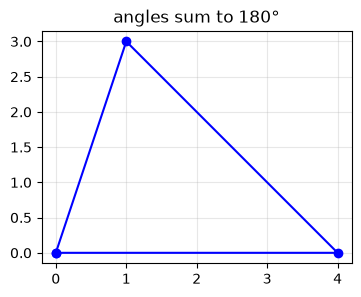

In [3]:
import numpy as np
import matplotlib.pyplot as plt

# Take any triangle, measure its three angles from the corner points, and add them.
A = np.array([0.0, 0.0]); B = np.array([4.0, 0.0]); C = np.array([1.0, 3.0])

def angle_at(P, Q, R):
    # angle at vertex P, between the rays P->Q and P->R, using the dot-product formula:
    u, v = Q - P, R - P
    cos = np.dot(u, v) / (np.linalg.norm(u) * np.linalg.norm(v))  # np.dot = dot product; norm = length
    return np.degrees(np.arccos(np.clip(cos, -1, 1)))             # arccos -> angle; clip avoids tiny errors

a = angle_at(A, B, C); b = angle_at(B, A, C); g = angle_at(C, A, B)
print(f"angles: {a:.1f}, {b:.1f}, {g:.1f}  -> sum = {a+b+g:.1f} degrees")

tri = np.array([A, B, C, A])               # close the triangle by repeating A at the end
plt.figure(figsize=(4, 4)); plt.plot(tri[:, 0], tri[:, 1], 'b-o')
plt.gca().set_aspect('equal'); plt.title("angles sum to 180°"); plt.grid(alpha=0.3); plt.show()


## 5. The Pythagorean theorem

For a **right** triangle (one $90^\circ$ angle), name the two short sides (the **legs**)
$a$ and $b$, and the longest side opposite the right angle (the **hypotenuse**) $c$.

**Theorem (Pythagoras).** $\;a^2 + b^2 = c^2.$

**Proof (by rearrangement).** Take a big square of side $a+b$. Its area is $(a+b)^2$.
Place four copies of the right triangle inside it, in two different ways:
- **Way 1:** the four triangles leave a tilted square of side $c$ in the middle, area $c^2$.
- **Way 2:** the four triangles leave two small squares, of areas $a^2$ and $b^2$.

The four triangles have the same total area both times, and the big square is the same, so
the leftover areas are equal:
$$c^2 = a^2 + b^2.$$
∎ (Algebraically: $(a+b)^2 = 4\cdot\tfrac12 ab + c^2 \Rightarrow a^2+2ab+b^2 = 2ab + c^2
\Rightarrow a^2+b^2=c^2$.)


In [4]:
import numpy as np
import sympy as sp

# Algebraic check of the rearrangement proof: (a+b)^2 - 4*(1/2 ab) should equal a^2+b^2.
a, b = sp.symbols('a b', positive=True)
leftover = sp.expand((a + b)**2 - 4*sp.Rational(1, 2)*a*b)
print("middle square area c^2 =", leftover, " => c^2 = a^2 + b^2")

# Numeric check on the classic 3-4-5 right triangle:
a0, b0 = 3.0, 4.0
c0 = np.hypot(a0, b0)                       # np.hypot(a,b) computes sqrt(a^2+b^2) safely
print(f"legs 3 and 4 -> hypotenuse = {c0}  (since 3^2+4^2 = {3**2+4**2} = 5^2)")


middle square area c^2 = a**2 + b**2  => c^2 = a^2 + b^2
legs 3 and 4 -> hypotenuse = 5.0  (since 3^2+4^2 = 25 = 5^2)


## 6. Perimeter, area, and circles

**Perimeter** = distance around the edge. **Area** = amount of surface inside.

| Shape | Perimeter | Area |
|---|---|---|
| Rectangle ($w\times h$) | $2(w+h)$ | $w\,h$ |
| Triangle (base $b$, height $h$) | sum of sides | $\tfrac12 b\,h$ |
| Circle (radius $r$) | $2\pi r$ (circumference) | $\pi r^2$ |

The number $\pi \approx 3.14159\dots$ is the ratio (circumference)/(diameter), the **same**
for every circle. It is irrational (like $\sqrt2$ from lesson 1).


circle r=2.0: circumference = 2*pi*r = 12.5664, area = pi*r^2 = 12.5664


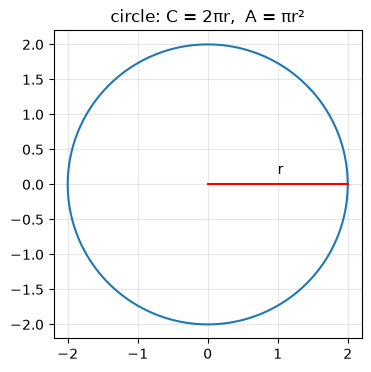

In [5]:
import numpy as np
import matplotlib.pyplot as plt

r = 2.0
theta = np.linspace(0, 2*np.pi, 200)       # 200 angles all the way around the circle
x, y = r*np.cos(theta), r*np.sin(theta)     # points on a circle of radius r (parametric form)

print(f"circle r={r}: circumference = 2*pi*r = {2*np.pi*r:.4f}, area = pi*r^2 = {np.pi*r**2:.4f}")

plt.figure(figsize=(4, 4)); plt.plot(x, y); plt.plot([0, r], [0, 0], 'r')  # radius drawn in red
plt.text(r/2, 0.15, "r"); plt.gca().set_aspect('equal'); plt.grid(alpha=0.3)
plt.title("circle: C = 2πr,  A = πr²"); plt.show()


## 7. Coordinate geometry — the bridge to algebra (and AI)

Put a grid on the plane: each point gets coordinates $(x, y)$. Now geometry becomes
algebra. For points $P=(x_1,y_1)$ and $Q=(x_2,y_2)$:

- **Distance** (straight-line, from Pythagoras):
  $$ d(P,Q) = \sqrt{(x_2-x_1)^2 + (y_2-y_1)^2}. $$
- **Midpoint** (the point exactly halfway):
  $$ M = \left( \frac{x_1+x_2}{2},\ \frac{y_1+y_2}{2} \right). $$
- **Slope** of the line through them (how steep it is):
  $$ m = \frac{y_2 - y_1}{x_2 - x_1} \quad (x_1 \neq x_2). $$

**Why distance comes from Pythagoras.** The horizontal gap is $|x_2-x_1|$, the vertical gap
is $|y_2-y_1|$. They are the two legs of a right triangle, and $d$ is the hypotenuse, so
$d^2 = (x_2-x_1)^2 + (y_2-y_1)^2$. ∎

> **Why AI cares:** this exact distance formula, extended from 2 numbers to thousands of
> numbers, is the **Euclidean distance** between data points and the **length (norm)** of a
> vector. "How similar are two things?" often means "how small is this distance?".


distance = 5.0000  (check: sqrt(4^2+3^2)=sqrt(25)=5)
midpoint = (np.float64(3.0), np.float64(2.5)),  slope = 0.75


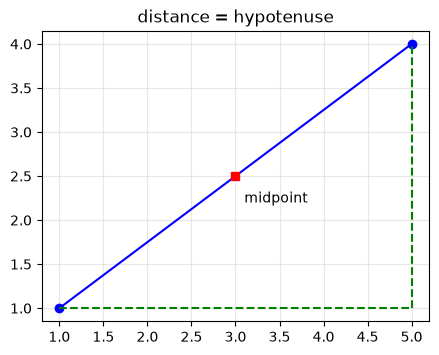

In [6]:
import numpy as np
import matplotlib.pyplot as plt

P = np.array([1.0, 1.0]); Q = np.array([5.0, 4.0])

# np.linalg.norm(Q - P) computes sqrt of the sum of squared differences = the distance.
dist = np.linalg.norm(Q - P)
mid  = (P + Q) / 2                          # element-wise average gives the midpoint
slope = (Q[1] - P[1]) / (Q[0] - P[0])       # rise over run
print(f"distance = {dist:.4f}  (check: sqrt(4^2+3^2)=sqrt(25)=5)")
print(f"midpoint = {tuple(mid)},  slope = {slope}")

# Picture: the points, the line, and the right triangle (legs = the x-gap and y-gap).
plt.figure(figsize=(5, 4))
plt.plot([P[0], Q[0]], [P[1], Q[1]], 'b-o')                 # the segment PQ
plt.plot([P[0], Q[0]], [P[1], P[1]], 'g--')                 # horizontal leg
plt.plot([Q[0], Q[0]], [P[1], Q[1]], 'g--')                 # vertical leg
plt.plot(*mid, 'rs'); plt.text(mid[0]+0.1, mid[1]-0.3, "midpoint")
plt.grid(alpha=0.3); plt.gca().set_aspect('equal'); plt.title("distance = hypotenuse"); plt.show()


## Summary — what you should now be able to do

1. Name the basic objects (point, line, ray, segment, angle) and classify angles.
2. Use complementary / supplementary / **vertical** angles, and prove vertical angles equal.
3. Use parallel-line angle facts (corresponding, alternate, co-interior).
4. Prove and use the **triangle angle sum = 180°**.
5. State and prove the **Pythagorean theorem**, and use it.
6. Compute **perimeter and area** of rectangles, triangles, and circles.
7. Use **coordinate geometry**: distance, midpoint, slope — and see why distance is just
   Pythagoras, the seed of Euclidean distance in AI.


## Exercises (20)

Try each yourself first. The last block asks for proofs.

**A. Angles**
1. An angle is $37^\circ$. Find its complement and its supplement.
2. Two lines cross. One angle is $110^\circ$. Find the other three angles.
3. Two angles are complementary and one is twice the other. Find both.
4. A transversal crosses two parallel lines; one alternate interior angle is $65^\circ$. Find its partner and a co-interior angle.
5. Classify by size: $5^\circ$, $90^\circ$, $91^\circ$, $179^\circ$.

**B. Triangles & Pythagoras**
6. Two angles of a triangle are $40^\circ$ and $75^\circ$. Find the third.
7. A right triangle has legs $6$ and $8$. Find the hypotenuse.
8. A right triangle has hypotenuse $13$ and one leg $5$. Find the other leg.
9. Can a triangle have angles $90^\circ, 60^\circ, 40^\circ$? Explain.
10. Is the triangle with sides $5, 12, 13$ a right triangle? Check with Pythagoras.

**C. Area, circles, coordinates**
11. Find the area and perimeter of a rectangle $7 \times 3$.
12. Find the area of a triangle with base $10$ and height $4$.
13. A circle has radius $5$. Find its circumference and area (leave $\pi$ in the answer).
14. Find the distance between $(2,3)$ and $(7,15)$.
15. Find the midpoint and the slope of the segment from $(-1,2)$ to $(3,10)$.

**D. Proofs (raise the bar)**
16. Prove that two angles supplementary to the **same** angle are equal to each other.
17. Prove the triangle angle sum is $180^\circ$ (use a line through one vertex parallel to the opposite side).
18. Prove that in any triangle the **largest angle is opposite the longest side** is *not* asked — instead: prove the exterior angle of a triangle equals the sum of the two non-adjacent interior angles.
19. Prove the distance formula $d=\sqrt{(x_2-x_1)^2+(y_2-y_1)^2}$ from the Pythagorean theorem.
20. Prove that the midpoint $M=\big(\tfrac{x_1+x_2}{2},\tfrac{y_1+y_2}{2}\big)$ is equidistant from the two endpoints (same distance to each).


In [7]:
# Your work for exercises 1-5 (angles).


In [8]:
# Your work for exercises 6-10 (triangles & Pythagoras). Use np.hypot to check.


In [9]:
# Your work for exercises 11-15 (area, circles, coordinates). Use np.linalg.norm for distance.


In [10]:
# Your work for exercises 16-20 (proofs). Write proofs in a markdown cell; use code only to test.


## How to run this notebook with `uv`

From the project folder `C:\dev\math`:

```powershell
uv sync                 # install dependencies (first time / after changes)
uv run jupyter lab      # open JupyterLab, then open notebooks/03-geometry-essentials.ipynb
```

No new libraries this time (numpy, sympy, matplotlib were enough). Add any future library
with `uv add <name>`.
